In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
# 1 A) 
df = pd.read_csv('/kaggle/input/mental-health-and-technology-usage-dataset/mental_health_and_technology_usage_2024.csv')

num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

data_types = df.dtypes
print("\ndata types of each column:")
print(data_types)

categorical_vars = df.select_dtypes(include=['object','category']).columns.tolist()
continuous_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("\nCategorical variables:", categorical_vars)
print("Continuous variables:", continuous_vars)

Number of rows: 10000
Number of columns: 14

data types of each column:
User_ID                      object
Age                           int64
Gender                       object
Technology_Usage_Hours      float64
Social_Media_Usage_Hours    float64
Gaming_Hours                float64
Screen_Time_Hours           float64
Mental_Health_Status         object
Stress_Level                 object
Sleep_Hours                 float64
Physical_Activity_Hours     float64
Support_Systems_Access       object
Work_Environment_Impact      object
Online_Support_Usage         object
dtype: object

Categorical variables: ['User_ID', 'Gender', 'Mental_Health_Status', 'Stress_Level', 'Support_Systems_Access', 'Work_Environment_Impact', 'Online_Support_Usage']
Continuous variables: ['Age', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Sleep_Hours', 'Physical_Activity_Hours']


In [3]:
# 1 B)
numerical_columns = df.select_dtypes(include=['float64','int64']).columns
five_point_summary = df[numerical_columns].describe(percentiles=[0.25,0.5,0.75])
print(five_point_summary.loc[['min','25%','50%','75%','max']])

      Age  Technology_Usage_Hours  Social_Media_Usage_Hours  Gaming_Hours  \
min  18.0                  1.0000                      0.00          0.00   
25%  29.0                  3.7600                      1.98          1.26   
50%  42.0                  6.4250                      3.95          2.52   
75%  54.0                  9.2125                      5.99          3.79   
max  65.0                 12.0000                      8.00          5.00   

     Screen_Time_Hours  Sleep_Hours  Physical_Activity_Hours  
min               1.00         4.00                     0.00  
25%               4.52         5.26                     2.49  
50%               7.90         6.50                     4.99  
75%              11.50         7.76                     7.54  
max              15.00         9.00                    10.00  


In [8]:
# 1 C)

categorical_columns = df.select_dtypes(include=['object','category']).columns

for col in categorical_columns:
    print(f"Summary for categorical variable:{col}")
    
    num_categories = df[col].nunique()
    print(f"Number of categories: {num_categories}")
    
    category_couts = df[col].value_counts(normalize=True)*100
    print("Percenatge of observations in each category:")
    print(category_couts.to_string())

Summary for categorical variable:User_ID
Number of categories: 10000
Percenatge of observations in each category:
User_ID
USER-00001    0.01
USER-06671    0.01
USER-06664    0.01
USER-06665    0.01
USER-06666    0.01
USER-06667    0.01
USER-06668    0.01
USER-06669    0.01
USER-06670    0.01
USER-06672    0.01
USER-06662    0.01
USER-06673    0.01
USER-06674    0.01
USER-06675    0.01
USER-06676    0.01
USER-06677    0.01
USER-06678    0.01
USER-06679    0.01
USER-06663    0.01
USER-06661    0.01
USER-06564    0.01
USER-06651    0.01
USER-06644    0.01
USER-06645    0.01
USER-06646    0.01
USER-06647    0.01
USER-06648    0.01
USER-06649    0.01
USER-06650    0.01
USER-06652    0.01
USER-06660    0.01
USER-06653    0.01
USER-06654    0.01
USER-06655    0.01
USER-06656    0.01
USER-06657    0.01
USER-06658    0.01
USER-06659    0.01
USER-06680    0.01
USER-06681    0.01
USER-06682    0.01
USER-06710    0.01
USER-06703    0.01
USER-06704    0.01
USER-06705    0.01
USER-06706    0.01
USER

In [10]:
# 1 D)
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values>0])
print("\n")

numerical_vars = df.select_dtypes(include=['int64','float64'])

print('Outliers detection (using IQR method):')
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 =df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"column '{col}' number of outliers: {outliers.shape[0]}")
print("\n")

User_ID = 'User_ID'

if User_ID in df.columns:
    class_distribution = df[User_ID].value_counts(normalize=True)*100
    print("Class distribution in User_ID variables:")
    print(class_distribution)
    print("\n")

Missing values in each column:
Series([], dtype: int64)


Outliers detection (using IQR method):
column 'Age' number of outliers: 0
column 'Technology_Usage_Hours' number of outliers: 0
column 'Social_Media_Usage_Hours' number of outliers: 0
column 'Gaming_Hours' number of outliers: 0
column 'Screen_Time_Hours' number of outliers: 0
column 'Sleep_Hours' number of outliers: 0
column 'Physical_Activity_Hours' number of outliers: 0


Class distribution in User_ID variables:
User_ID
USER-00001    0.01
USER-06671    0.01
USER-06664    0.01
USER-06665    0.01
USER-06666    0.01
              ... 
USER-03334    0.01
USER-03335    0.01
USER-03336    0.01
USER-03337    0.01
USER-10000    0.01
Name: proportion, Length: 10000, dtype: float64




In [11]:
#2 A)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

numerical_vars = df.select_dtypes(include=['int64','float64'])
imputer = SimpleImputer(strategy='mean')
df[numerical_vars.columns] = imputer.fit_transform(numerical_vars)

categorical_vars = df.select_dtypes(include=['object','category'])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_vars.columns] = imputer_cat.fit_transform(categorical_vars)

print("Missing values handled.")
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQr=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)
print("Outliers hanlded using capping.")

Missing values handled.
Outliers hanlded using capping.


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


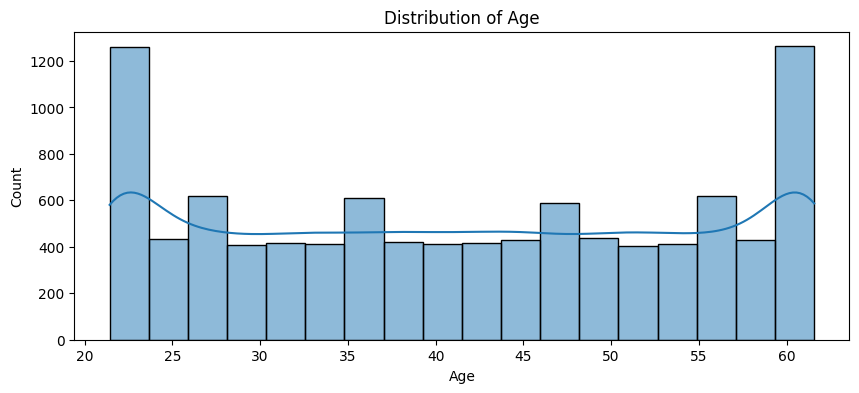

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


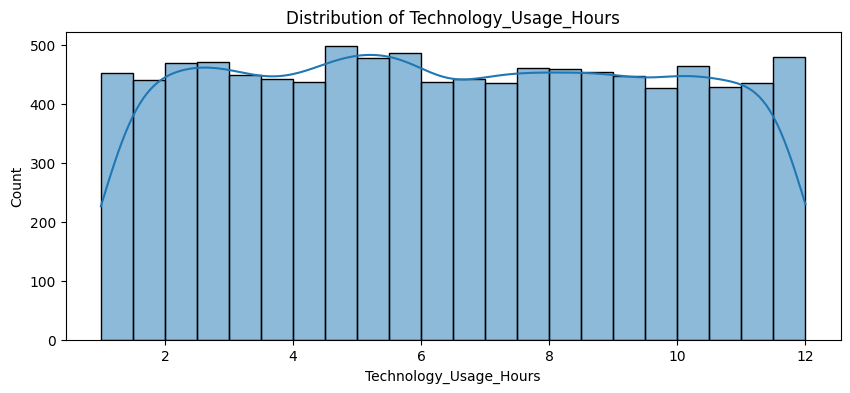

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


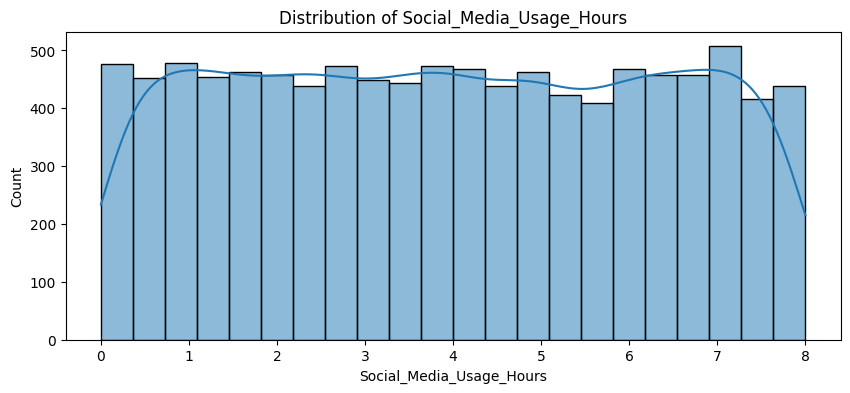

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


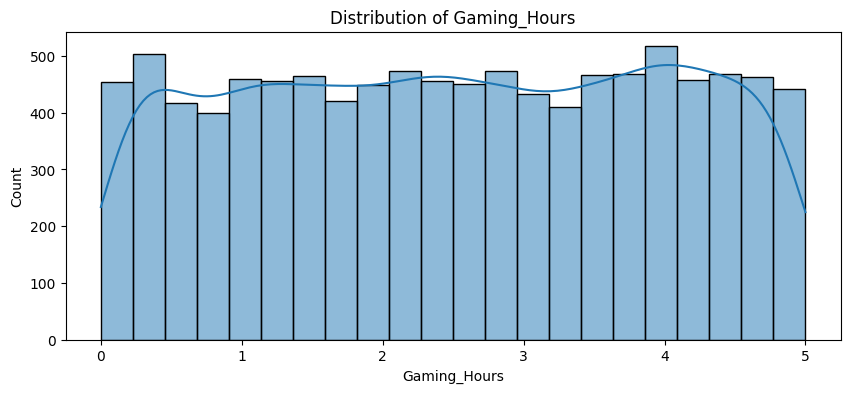

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


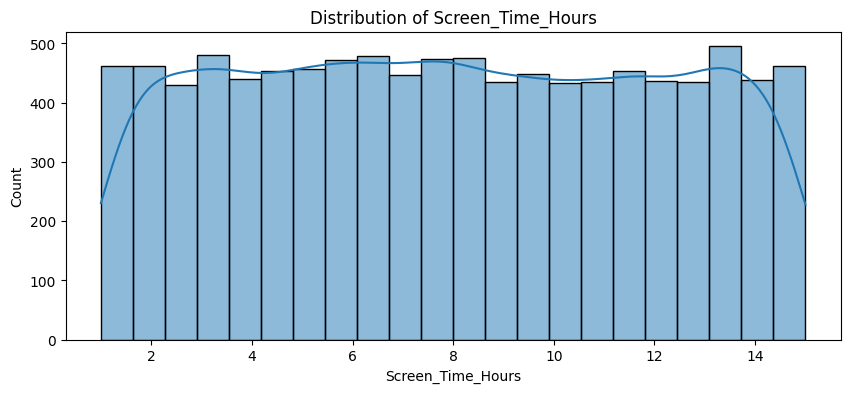

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


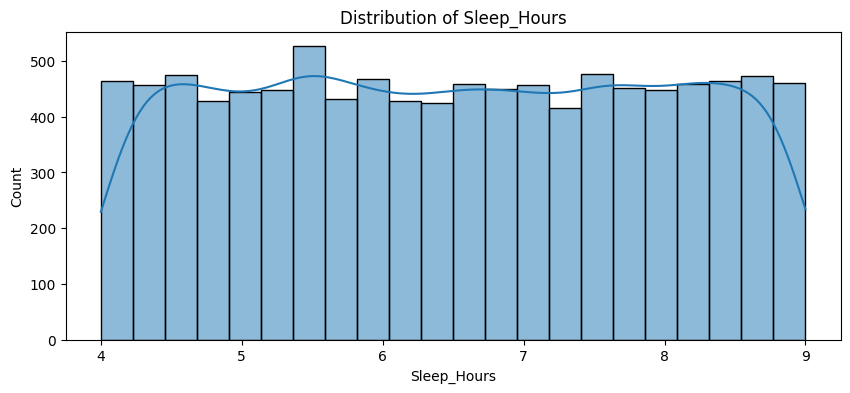

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


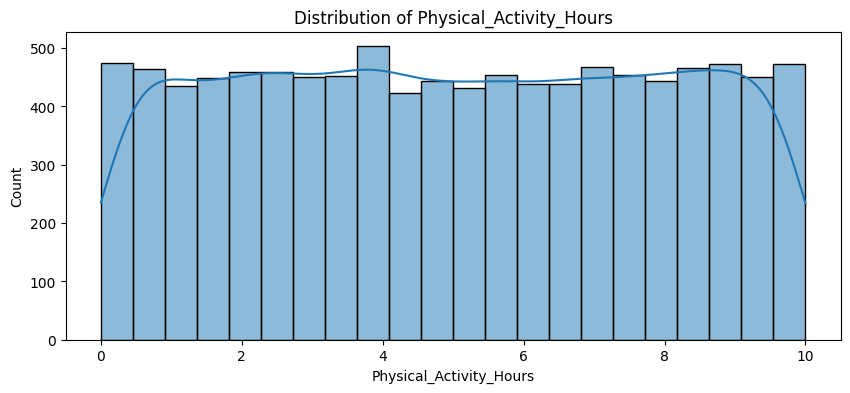

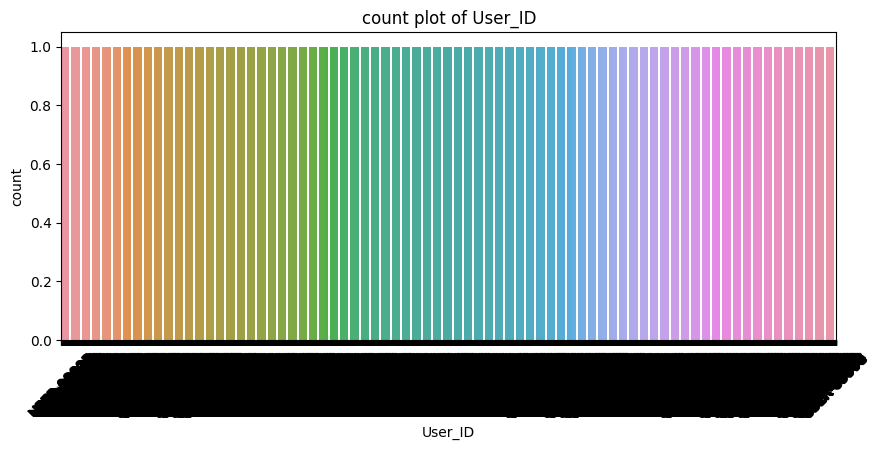

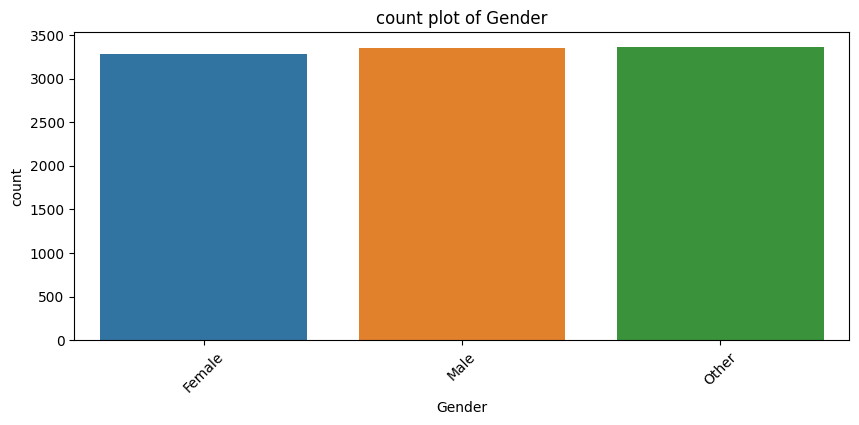

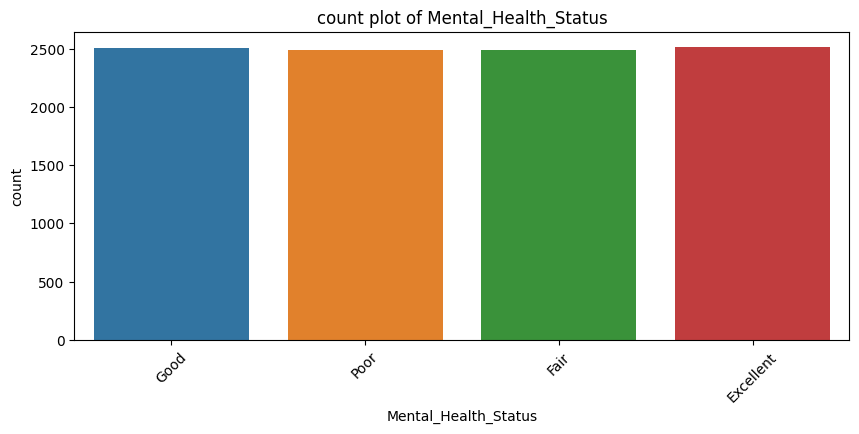

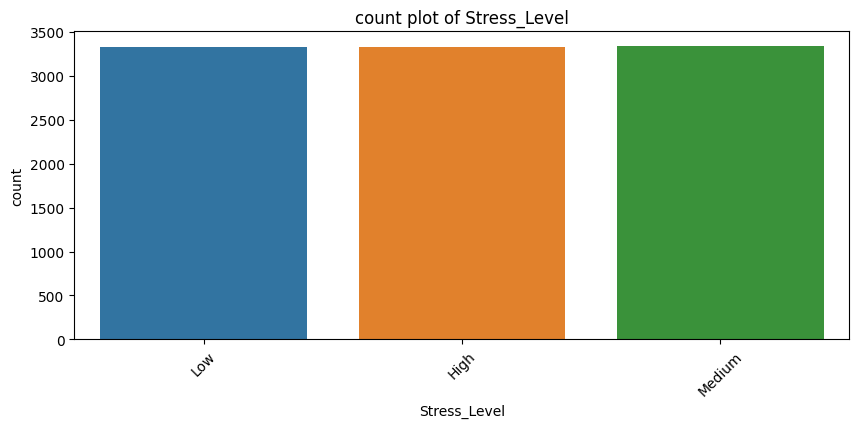

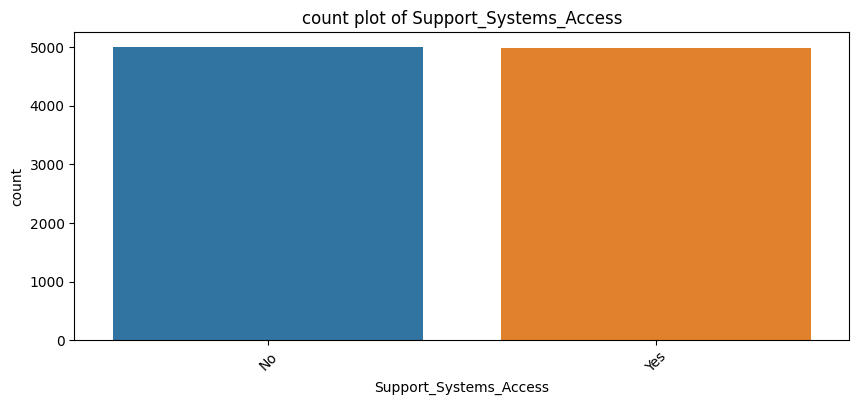

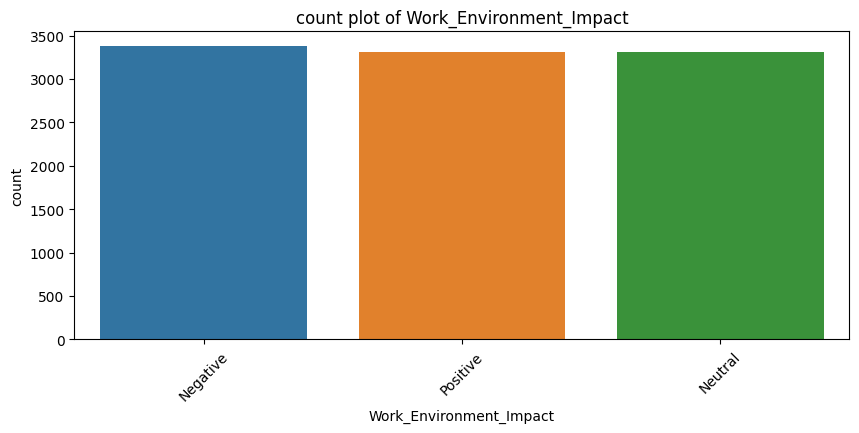

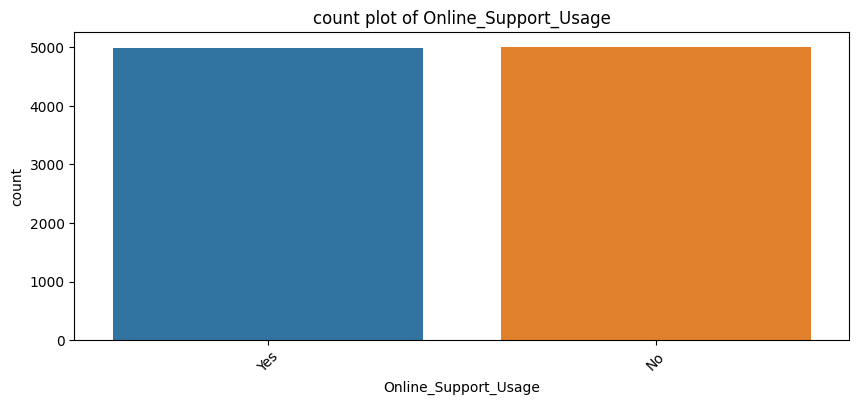

Correlation with Age variables:
Technology_Usage_Hours      0.018054
Social_Media_Usage_Hours    0.009629
Screen_Time_Hours           0.007248
Gaming_Hours                0.006305
Sleep_Hours                -0.002021
Physical_Activity_Hours    -0.004138
Name: Age, dtype: float64


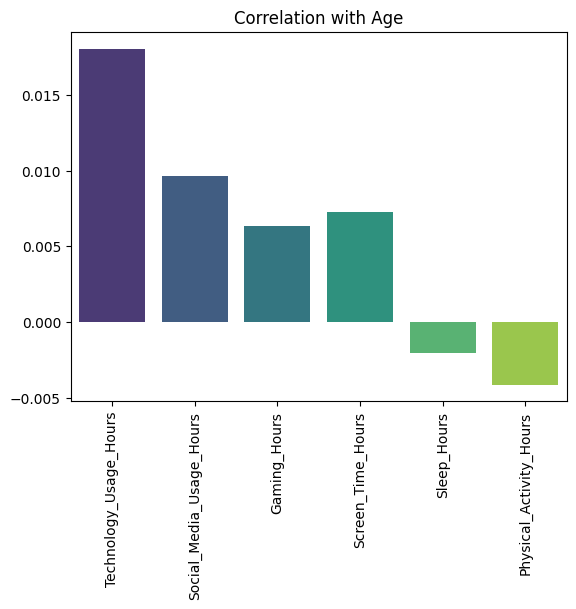

In [15]:
# 2 B)
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
    
categorical_vars = df.select_dtypes(include=['object','category'])
for col in categorical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(f'count plot of {col}')
    plt.xticks(rotation=45)
    plt.show()
    
Age = 'Age'
if Age in df.columns:
    df_numerical = df.select_dtypes(include=['int64','float64'])
    correlations = df_numerical.corr()[Age].drop(Age)
    
    print("Correlation with Age variables:")
    print(correlations.sort_values(ascending=False))
    sns.barplot(x=correlations.index,y=correlations.values,palette='viridis')
    plt.title(f'Correlation with {Age}')
    plt.xticks(rotation=90)
    plt.show()

In [8]:
# 2 C)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
variables_to_exclude = ['Support_Systems_Access','Work_Environment_Impact']
df_cleaned = df.drop(columns= variables_to_exclude)

Age = 'Age'
if Age in df_cleaned.columns:
    x = df_cleaned.drop(columns=[Age])
    y = df_cleaned[Age]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    scaler = StandardScaler()
    numerical_features = x_train.select_dtypes(include=['int64','float64']).columns
    x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
    x_test[numerical_features] = scaler.transform(x_test[numerical_features])
    
    print("Data preparation complete. the dataset is now ready for model creation.")

Data preparation complete. the dataset is now ready for model creation.


In [9]:
df.head()

,User_ID,Age,Gender,Technology_Usage_Hours,Social_Media_Usage_Hours,Gaming_Hours,Screen_Time_Hours,Mental_Health_Status,Stress_Level,Sleep_Hours,Physical_Activity_Hours,Support_Systems_Access,Work_Environment_Impact,Online_Support_Usage
0,USER-00001,23,Female,6.57,6.00,0.68,12.36,Good,Low,8.01,6.71,No,Negative,Yes
1,USER-00002,21,Male,3.01,2.57,3.74,7.61,Poor,High,7.28,5.88,Yes,Positive,No
2,USER-00003,51,Male,3.04,6.14,1.26,3.16,Fair,High,8.04,9.81,No,Negative,No
3,USER-00004,25,Female,3.84,4.48,2.59,13.08,Excellent,Medium,5.62,5.28,Yes,Negative,Yes
4,USER-00005,53,Male,1.20,0.56,0.29,12.63,Good,Low,5.55,4.00,No,Positive,Yes


In [10]:
# 2 D)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_vars = df.select_dtypes(include=['object','category']).columns

Label_encoders = {}
for col in categorical_vars:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    Label_encoders[col] = le
    
print("Label Encoding completed.")

df_encoded = pd.get_dummies(df,columns=categorical_vars,drop_first=True)
print("One-Hot Encoding completed")

preprocessor = ColumnTransformer(
transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_vars)
    
],
remainder='passthrough')

x= preprocessor.fit_transform(df)
print("ColumnTransformer completed.")

Label Encoding completed.
One-Hot Encoding completed
ColumnTransformer completed.


In [11]:
# 2 E)
from sklearn.model_selection import train_test_split
from scipy import stats

Age = 'Age'
if Age in df.columns:
    x=df.drop(columns=[Age])
    y=df[Age]
    
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    def compare_distributions(df1,df2,columns):
        for col in columns:
            if df1[col].dtype in ['int64','float64']:
                _,p_value = stats.ks_2samp(df1[col],df2[col])
                print(f"kolmogorov-SMirnov test p-value for {col}: {p_value:.4f}")
                if p_value <0.05:
                    print(f"Distribution of {col} is significantly different between training and testing sets.")
                else:
                    print(f"Distribution of {col} is similar between training ans testing sets.")
            else:
                contingency = pd.crosstab(df1[col], df2[col])
                _,p_value, _,_ = stats.chi2_contingency(contingency)
                print(f"Chi-square test p-value for {col}: {p_value:.4f}")
                if p_value < 0.05:
                    print(F"Distribution of {col} is significantly differnt between training and testing sets.")
                else:
                    print(F"Distribution of {col} is similar between trining and testing sets.")
    compare_distributions(pd.concat([x_train,y_train],axis=1), pd.concat([x_test,y_test], axis=1),x.columns)

kolmogorov-SMirnov test p-value for User_ID: 0.3296
Distribution of User_ID is similar between training ans testing sets.
kolmogorov-SMirnov test p-value for Gender: 0.5197
Distribution of Gender is similar between training ans testing sets.
kolmogorov-SMirnov test p-value for Technology_Usage_Hours: 0.3984
Distribution of Technology_Usage_Hours is similar between training ans testing sets.
kolmogorov-SMirnov test p-value for Social_Media_Usage_Hours: 0.6571
Distribution of Social_Media_Usage_Hours is similar between training ans testing sets.
kolmogorov-SMirnov test p-value for Gaming_Hours: 0.5586
Distribution of Gaming_Hours is similar between training ans testing sets.
kolmogorov-SMirnov test p-value for Screen_Time_Hours: 0.6203
Distribution of Screen_Time_Hours is similar between training ans testing sets.
kolmogorov-SMirnov test p-value for Mental_Health_Status: 0.9779
Distribution of Mental_Health_Status is similar between training ans testing sets.
kolmogorov-SMirnov test p-va

In [12]:
# 3 A)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

Age = 'Age'
if Age in df.columns:
    x=df.drop(columns=[Age])
    y=df[Age]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(f"Mean squared error of Linear Regression model:{mse:.4f}")
    print(f"R^2 score of Linear regression model: {r2:.4f}")

Mean squared error of Linear Regression model:197.6949
R^2 score of Linear regression model: -0.0033


In [17]:
# 3 B)
from sklearn.metrics import accuracy_score

y_true = [0,1,1,0,1,0,1,1,0,0]
y_pred = [0,1,0,0,1,0,1,0,0,1]
accuracy = accuracy_score(y_true,y_pred)

print(f"Overall Accuracy: {accuracy:.2f}")

if accuracy>=0.80:
    print("The accuracy is good.the model is performaing well.")
elif 0.60 <=accuracy <0.80:
    print("The accuracy is moderate ,The model may need improvemnet.")
else:
    print("The accuracy is low.The model requires significant improvements.")
    
# Key Observations
# 1) Accuracy Calculation: The accuracy_score function compares the true labels (y_true) with the predicted
# labels(y_pred) and calculates the proportion of correct predictions.
# 2) Commentary on Accuracy: The code includes conditional statements to provide 
#                              a basic evaluation of the accuracy:
# Good Accuracy(> 80%): indicates that the model is performaing well.
# Moderate Accuracy(60% to 80%) : suggetss that there may be room for improvement.
# Low Accuracy(<60%): Indicates that the model's performance is poor, and significant adjustment or
#                     different approaches might be needed.



Overall Accuracy: 0.70
The accuracy is moderate ,The model may need improvemnet.


In [20]:
# 3 C)
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

data = load_iris()
x = data.data
y=data.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

precision = precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')

print("Precision:", precision)
print("Recall:",recall)
print("Fl score:",f1)

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

Precision: 1.0
Recall: 1.0
Fl score: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [22]:
# 3 d)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

data = load_iris()
x=data.data
y=data.target
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators':[50,100,200],
    'model__max_depth': [None,10,20,30]
}

grid_search = GridSearchCV(pipeline,param_grid,cv=5,scoring='accuracy')
grid_search.fit(x_train,y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nBest parameters:", grid_search.best_params_)


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Best parameters: {'model__max_depth': None, 'model__n_estimators': 50}


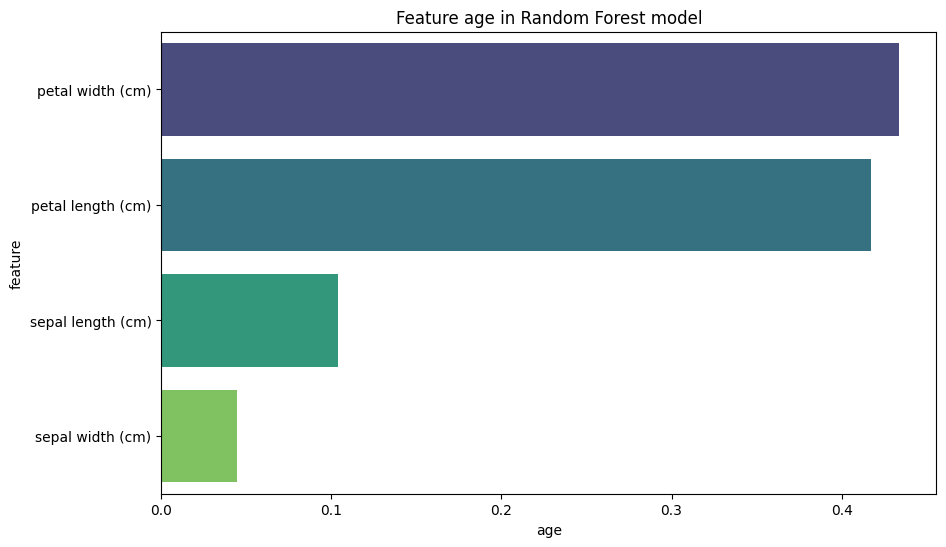

In [33]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_iris()
x= pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier (n_estimators=100,random_state=42)
model.fit(x_train,y_train)

feature_importances = model.feature_importances_

feature_Age_df = pd.DataFrame({
    'feature': x.columns,
    'age': feature_importances
    
}).sort_values(by='age',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='age', y='feature',data=feature_Age_df,palette='viridis')
plt.title('Feature age in Random Forest model')
plt.xlabel('age')
plt.ylabel('feature')
plt.show()
